# **Experiment Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [ ]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT1"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

print("###### Install required Python packages ######")
! pip install -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}


###### Install required Python packages ######

###### Connect to personal Google Drive ######
Mounted at /content/gdrive

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT1/data
/content/gdrive/MyDrive/36106/assignment/AT1/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

### 0.d Import Packages

In [ ]:
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## A. Data Understanding

In [ ]:
# Load training data
X_train = pd.read_csv(folder_path / 'X_train.csv')
y_train = pd.read_csv(folder_path / 'y_train.csv')

In [ ]:
# Load validation data
X_val = pd.read_csv(folder_path / 'X_val.csv')
y_val = pd.read_csv(folder_path / 'y_val.csv')

In [ ]:
# Load testing data
X_test = pd.read_csv(folder_path / 'X_test.csv')
y_test = pd.read_csv(folder_path / 'y_test.csv')

---
## B. Feature Selection


In [ ]:
# <Student to fill this section>

features_list = ["advertised_date", "number_of_bedrooms", "rent", "floor_area", "level", "suburb", "furnished", "tenancy_preference", "number_of_bathrooms", "point_of_contact"]

---
## C. Train Machine Learning Model

### C.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

### C.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [ ]:
n_neighbors = [ 5, 7, 8, 10, 15, 20, 30, 40]
p = [1, 2]

### C.3 Fit Model

In [ ]:
for n_neighbor in n_neighbors:
    for p_value in p:
        # Create the ElasticNet model with the current alpha and l1_ratio
        # Changed 'n_neighbor' to 'n_neighbors' and 'p_value' to 'p'
        model = KNeighborsRegressor(n_neighbors=n_neighbor, p=p_value)

        # Train the model
        model.fit(X_train, y_train)

### C.4 Model Technical Performance

> Provide some explanations on model performance


In [ ]:
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_squared_error as mse

In [ ]:
# Initialize lists to store results
train_mse_values = []
val_mse_values = []
train_rmse_values = []
val_rmse_values = []
n_neighbor_list = []
p_value_list = []
y_train_preds = []
y_val_preds = []

# Loop through each combination of n_neighbor and p
for n_neighbor in n_neighbors:
    for p_value in p:
        # Create the KNN model with the current n_neighbor and p
        # Changed 'n_neighbor' to 'n_neighbors' and 'p_value' to 'p'
        model = KNeighborsRegressor(n_neighbors=n_neighbor, p=p_value)

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions on the training and validation sets
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Calculate performance metrics for training data
        train_mse = mse(y_train, y_train_pred)
        train_rmse = rmse(y_train, y_train_pred)

        # Calculate performance metrics for validation data
        val_mse = mse(y_val, y_val_pred)
        val_rmse = rmse(y_val, y_val_pred)

        # Append the results to the lists
        n_neighbor_list.append(n_neighbor)
        p_value_list.append(p_value)
        train_mse_values.append(train_mse)
        val_mse_values.append(val_mse)
        train_rmse_values.append(train_rmse)
        val_rmse_values.append(val_rmse)
        y_train_preds.append(y_train_pred)
        y_val_preds.append(y_val_pred)

# After the loop, organize the results into a DataFrame
df = pd.DataFrame({
    'n_neighbor': n_neighbor_list,
    'p': p_value_list,
    'Train MSE': train_mse_values,
    'Train RMSE': train_rmse_values,
    'Validation MSE': val_mse_values,
    'Validation RMSE': val_rmse_values,
})

# Sort the DataFrame by Validation RMSE
df_sorted = df.sort_values(by='Validation RMSE')

# Format the DataFrame to avoid scientific notation
pd.set_option('display.float_format', '{:.4f}'.format)

# Display the sorted DataFrame
display(df_sorted)

,n_neighbor,p,Train MSE,Train RMSE,Validation MSE,Validation RMSE
2,7,1,6293.2702,79.3301,1243.7796,35.2673
0,5,1,5866.2453,76.5914,1439.0291,37.9345
5,8,2,6601.8697,81.2519,1440.5380,37.9544
3,7,2,6385.5463,79.9096,1464.6770,38.2711
7,10,2,6877.7462,82.9322,1468.6322,38.3227
1,5,2,5864.5236,76.5802,1536.8101,39.2022
12,30,1,7460.0125,86.3714,1696.1997,41.1849
6,10,1,6833.6726,82.6660,1746.5586,41.7918
10,20,1,7267.8595,85.2517,1780.0480,42.1906
14,40,1,7628.5725,87.3417,1828.6600,42.7628


In [ ]:
# Define lists to store results for the test set
test_mse_values = []
test_rmse_values = []
y_test_preds = []

# Loop through each combination of n_neighbors and p
for n_neighbor in n_neighbors:
    for p_value in p:
        # Create the KNN model with the current n_neighbors and p
        # Changed 'n_neighbor' to 'n_neighbors' and 'p_value' to 'p'
        model = KNeighborsRegressor(n_neighbors=n_neighbor, p=p_value)

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions on the test set
        y_test_pred = model.predict(X_test)

        # Calculate performance metrics for the test data
        test_mse = mse(y_test, y_test_pred)
        test_rmse = rmse(y_test, y_test_pred)

        # Append the results to the lists
        test_mse_values.append(test_mse)
        test_rmse_values.append(test_rmse)
        y_test_preds.append(y_test_pred)

# After the loop, organize the results into a DataFrame for easy comparison
df_test = pd.DataFrame({
    'n_neighbor': n_neighbor_list,
    'p': p_value_list,
    'Test MSE': test_mse_values,
    'Test RMSE': test_rmse_values,
})

# Sort the DataFrame by Test RMSE
df_test_sorted = df_test.sort_values(by='Test RMSE')

# Format the DataFrame to avoid scientific notation
pd.set_option('display.float_format', '{:.4f}'.format)

# Display the sorted results for the test set
display('Test Set Results (Sorted by RMSE):')
display(df_test_sorted)

'Test Set Results (Sorted by RMSE):'

,n_neighbor,p,Test MSE,Test RMSE
12,30,1,2394.5349,48.9340
14,40,1,2399.8907,48.9887
10,20,1,2553.0813,50.5280
15,40,2,2627.9648,51.2637
13,30,2,2651.1766,51.4896
8,15,1,2776.8782,52.6961
11,20,2,2876.0938,53.6292
9,15,2,3069.7677,55.4055
6,10,1,3094.9598,55.6324
7,10,2,3326.4713,57.6756


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.preprocessing import StandardScaler

# Define the hyperparameter distributions
param_distributions = {
    'n_neighbors': randint(5, 41),
    'p': [1, 2]
}

# Initialize the KNN model
knn_model = KNeighborsRegressor()

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_distributions,
    n_iter=20,  # Number of different combinations to try
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the randomized search
random_search.fit(X_train_scaled, y_train)

# Get the best parameters and the best score
best_params = random_search.best_params_
best_score = -random_search.best_score_

print(f'Best Parameters: {best_params}')
print(f'Best CV RMSE: {best_score}')

# Retrain the KNN model with the best parameters
best_knn_model = random_search.best_estimator_

# Make predictions
y_train_pred_best = best_knn_model.predict(X_train_scaled)
y_test_pred_best = best_knn_model.predict(X_test_scaled)

# Evaluate the final model
train_rmse_best = rmse(y_train, y_train_pred_best)
test_rmse_best = rmse(y_test, y_test_pred_best)

print(f'Training RMSE (Best Model): {train_rmse_best}')
print(f'Test RMSE (Best Model): {test_rmse_best}')

Best Parameters: {'n_neighbors': 33, 'p': 1}
Best CV RMSE: 68.13173027697779
Training RMSE (Best Model): 86.57067756636387
Test RMSE (Best Model): 49.056629024283815


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Define the KNN model and the hyperparameter grid
param_grid = {
    'n_neighbors': [ 5, 7, 8, 10, 15, 20, 30, 40],
    'p': [1, 2]
}

# Initialize the KNN model
knn_model = KNeighborsRegressor()

# Set up GridSearchCV to search over the hyperparameter grid
grid_search = GridSearchCV(estimator=knn_model, param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error')

# Normalize features (since KNN is sensitive to feature scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the grid search to the data (using scaled features)
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = -grid_search.best_score_  # since we used neg_root_mean_squared_error, we negate the score

print(f'Best Parameters: {best_params}')
print(f'Best CV RMSE: {best_score}')

# Now, we can retrain the KNN model with the best parameters on the entire training set and evaluate on the test set
best_knn_model = grid_search.best_estimator_

# Make predictions
y_train_pred_best = best_knn_model.predict(X_train_scaled)
y_test_pred_best = best_knn_model.predict(X_test_scaled)

# Evaluate the final model
train_rmse_best = rmse(y_train, y_train_pred_best)
test_rmse_best = rmse(y_test, y_test_pred_best)

print(f'Training RMSE (Best Model): {train_rmse_best}')
print(f'Test RMSE (Best Model): {test_rmse_best}')


Best Parameters: {'n_neighbors': 40, 'p': 1}
Best CV RMSE: 67.83406213403809
Training RMSE (Best Model): 87.34172875820353
Test RMSE (Best Model): 48.98873022593625


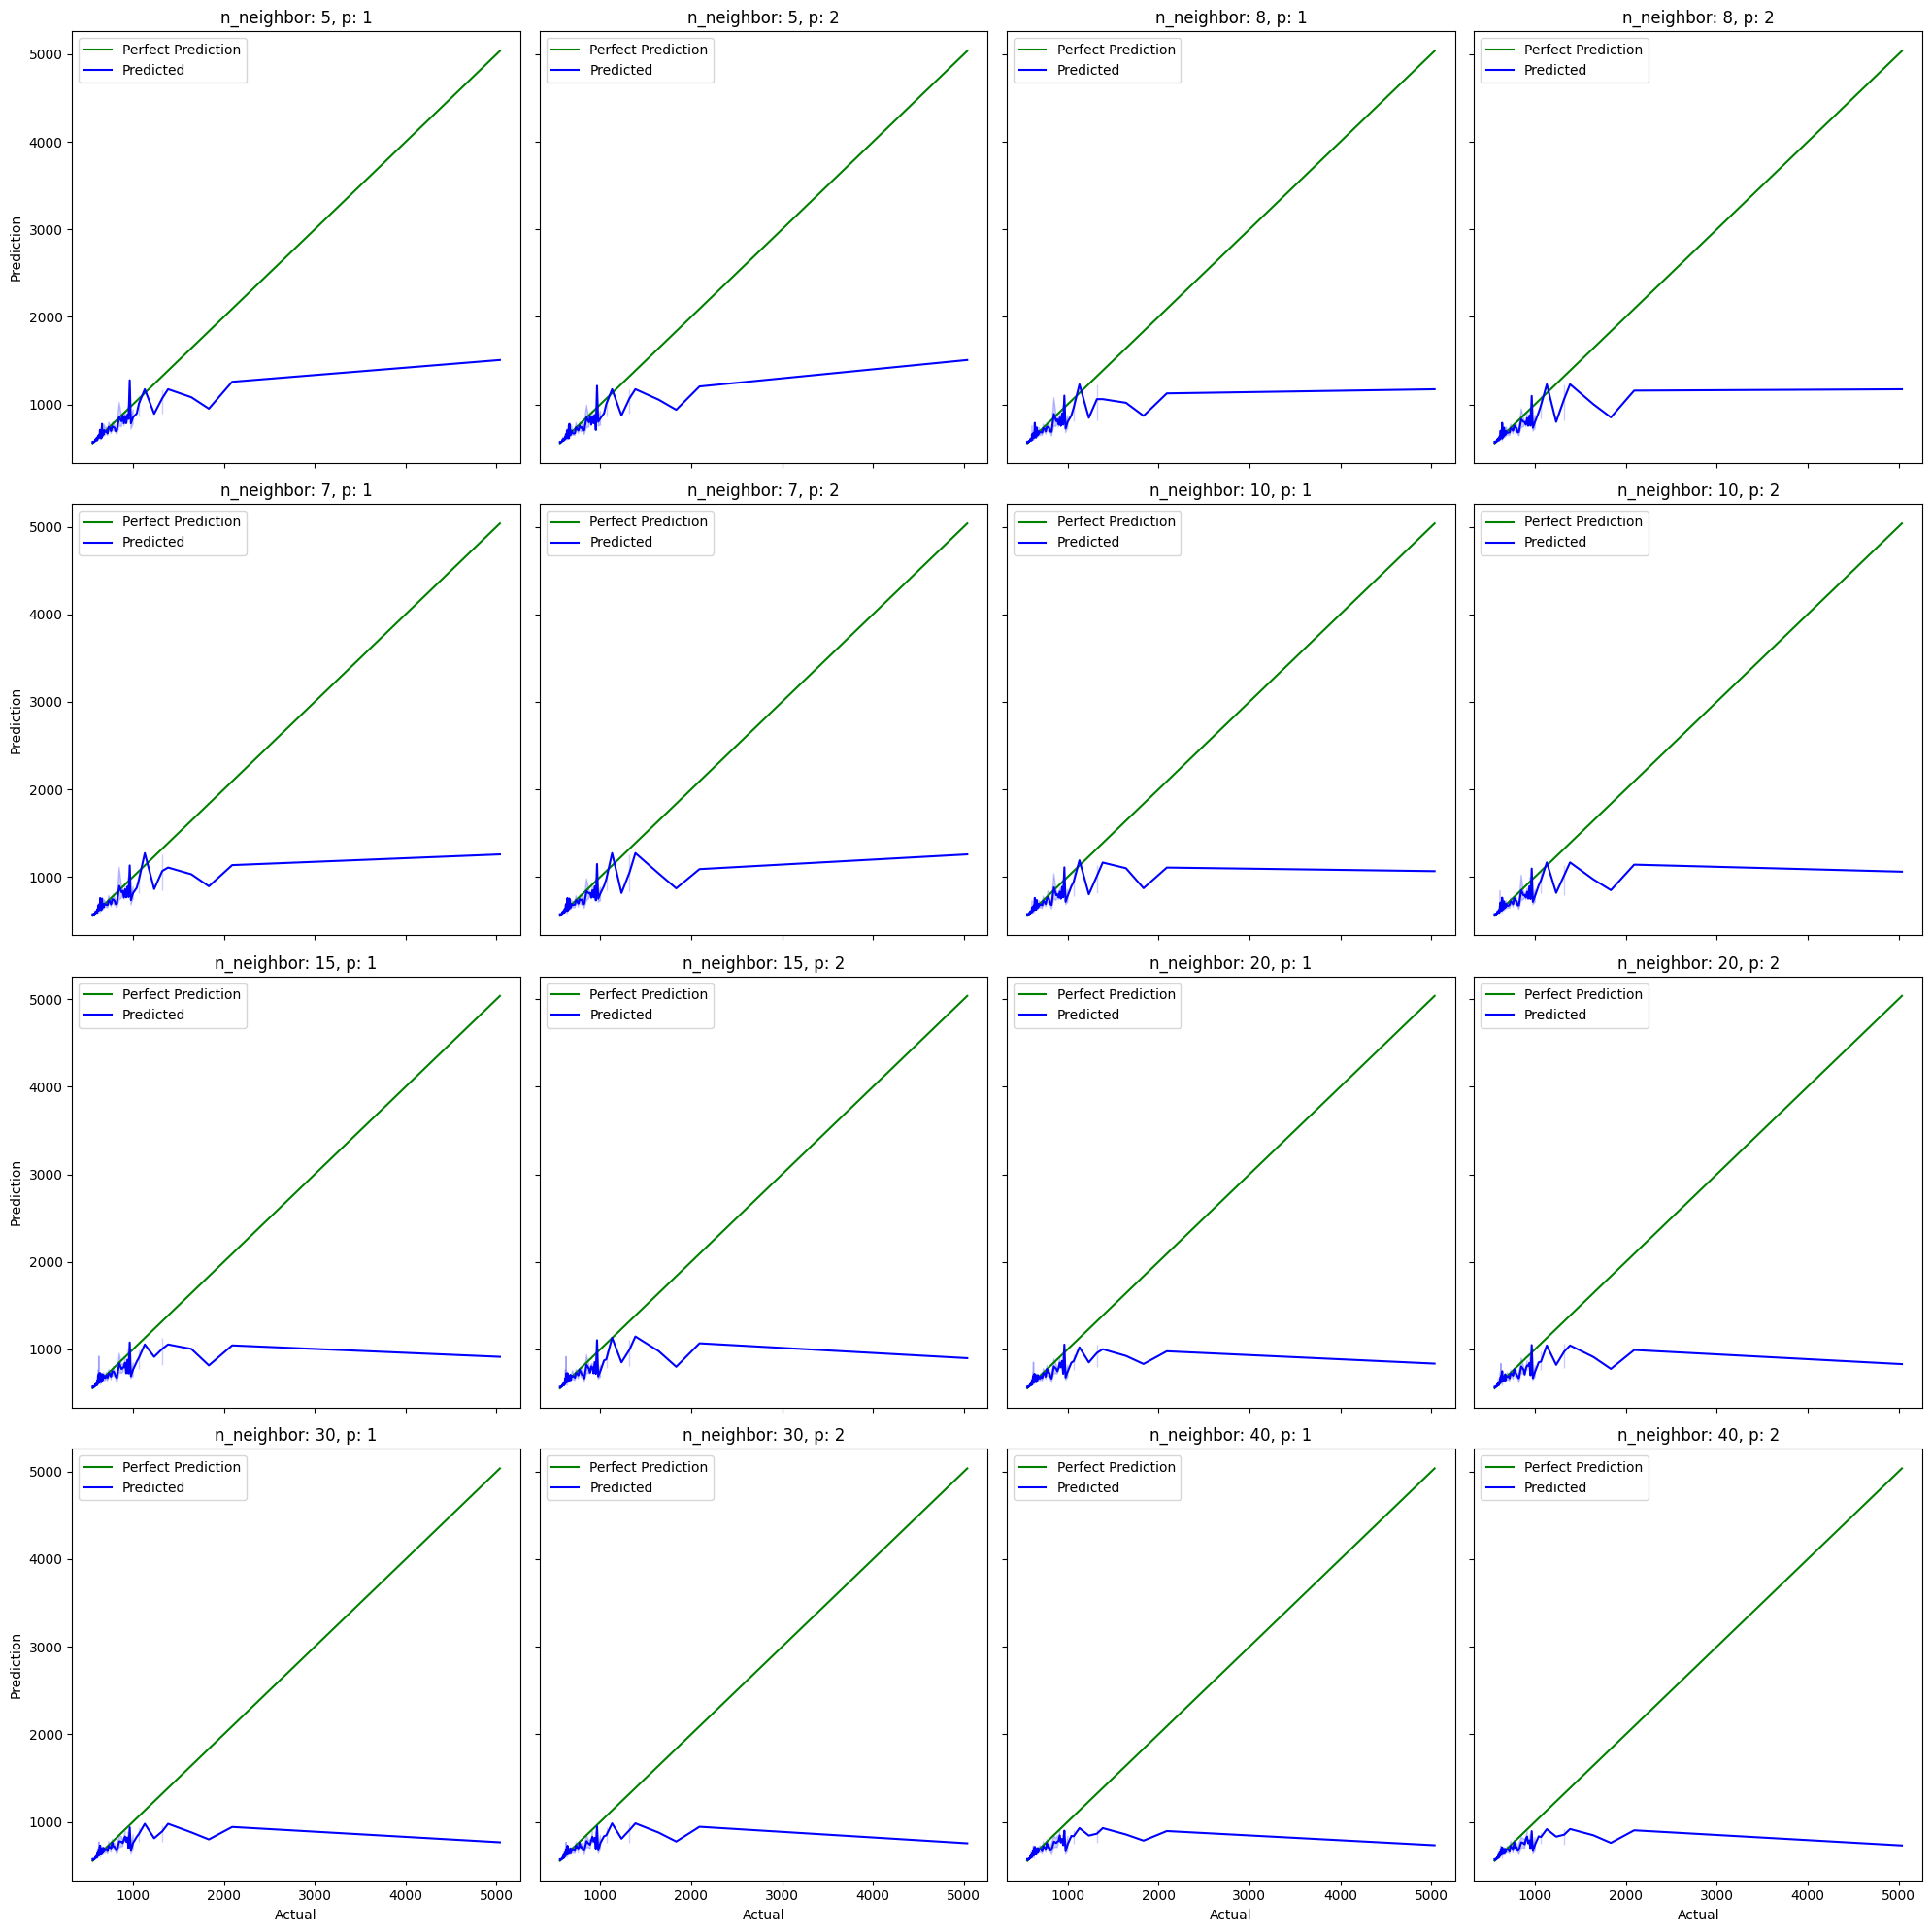

In [ ]:
# Visualize the predictions vs actual for each n_neighbor and p
# Assuming we have 16 combinations (8 n_neighbor * 2 p)
fig, axes = plt.subplots(4,4, figsize=(20, 20), sharex=True, sharey=True)
axes = axes.flatten()

for i, (n, P, y_train_pred) in enumerate(zip(n_neighbor_list, p_value_list, y_train_preds)):
    # Create DataFrame with actual and predicted values for training data
    df_train = pd.DataFrame({'Actual': y_train.values.flatten(), 'Prediction': y_train_pred.flatten()})

    # Plot the perfect prediction line (Actual == Prediction)
    sns.lineplot(x='Actual', y='Actual', data=df_train, ax=axes[i], color='green', label='Perfect Prediction')

    # Plot the predictions from the model (Training data)
    sns.lineplot(x='Actual', y='Prediction', data=df_train, ax=axes[i], color='blue', label='Predicted')

    # Set the title with alpha and l1_ratio value
    axes[i].set_title(f'n_neighbor: {n}, p: {P}')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Prediction')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

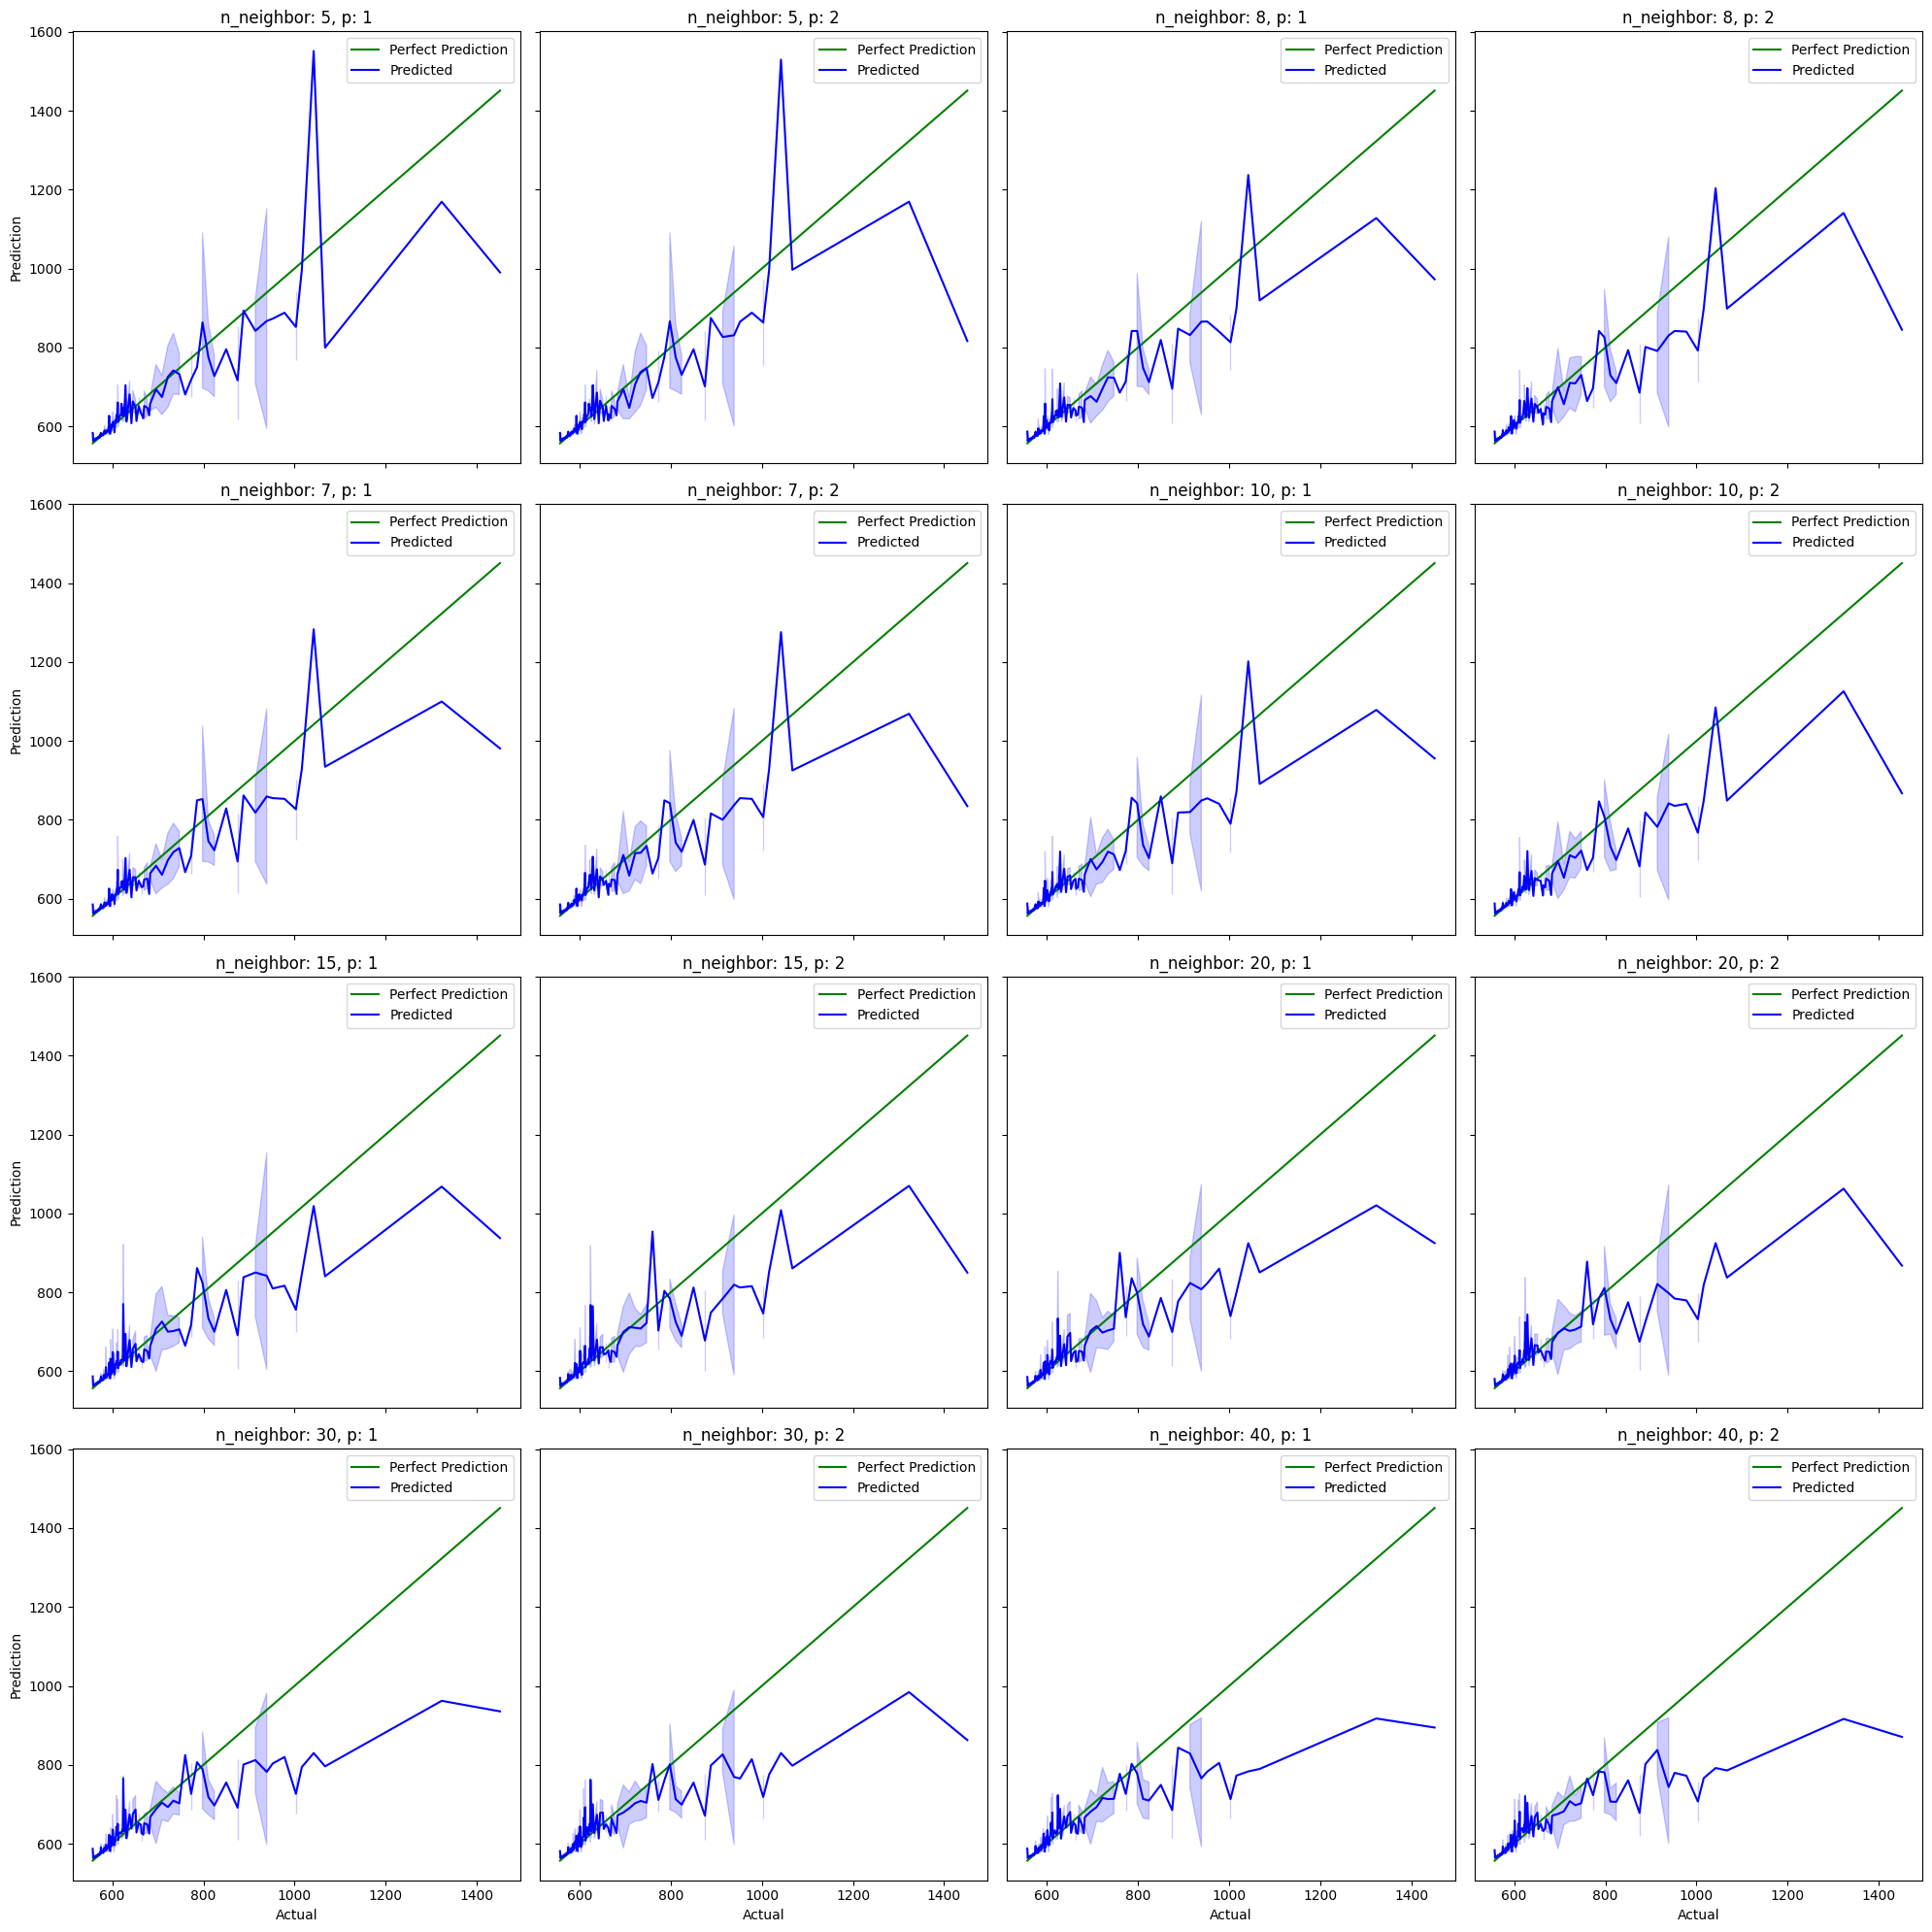

In [ ]:
# Visualize the predictions vs actual of validation set for each n_neighbor and p
# Assuming we have 16 combinations (8 n_neighbor * 2 p)
fig, axes = plt.subplots(4,4, figsize=(20, 20), sharex=True, sharey=True)
axes = axes.flatten()

for i, (n, P, y_val_pred) in enumerate(zip(n_neighbor_list, p_value_list, y_val_preds)):
    # Create DataFrame with actual and predicted values for validation data
    df_val = pd.DataFrame({'Actual': y_val.values.flatten(), 'Prediction': y_val_pred.flatten()})

    # Plot the perfect prediction line (Actual == Prediction)
    sns.lineplot(x='Actual', y='Actual', data=df_val, ax=axes[i], color='green', label='Perfect Prediction')

    # Plot the predictions from the model (validation data)
    sns.lineplot(x='Actual', y='Prediction', data=df_val, ax=axes[i], color='blue', label='Predicted')

    # Set the title with alpha and l1_ratio value
    axes[i].set_title(f'n_neighbor: {n}, p: {P}')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Prediction')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

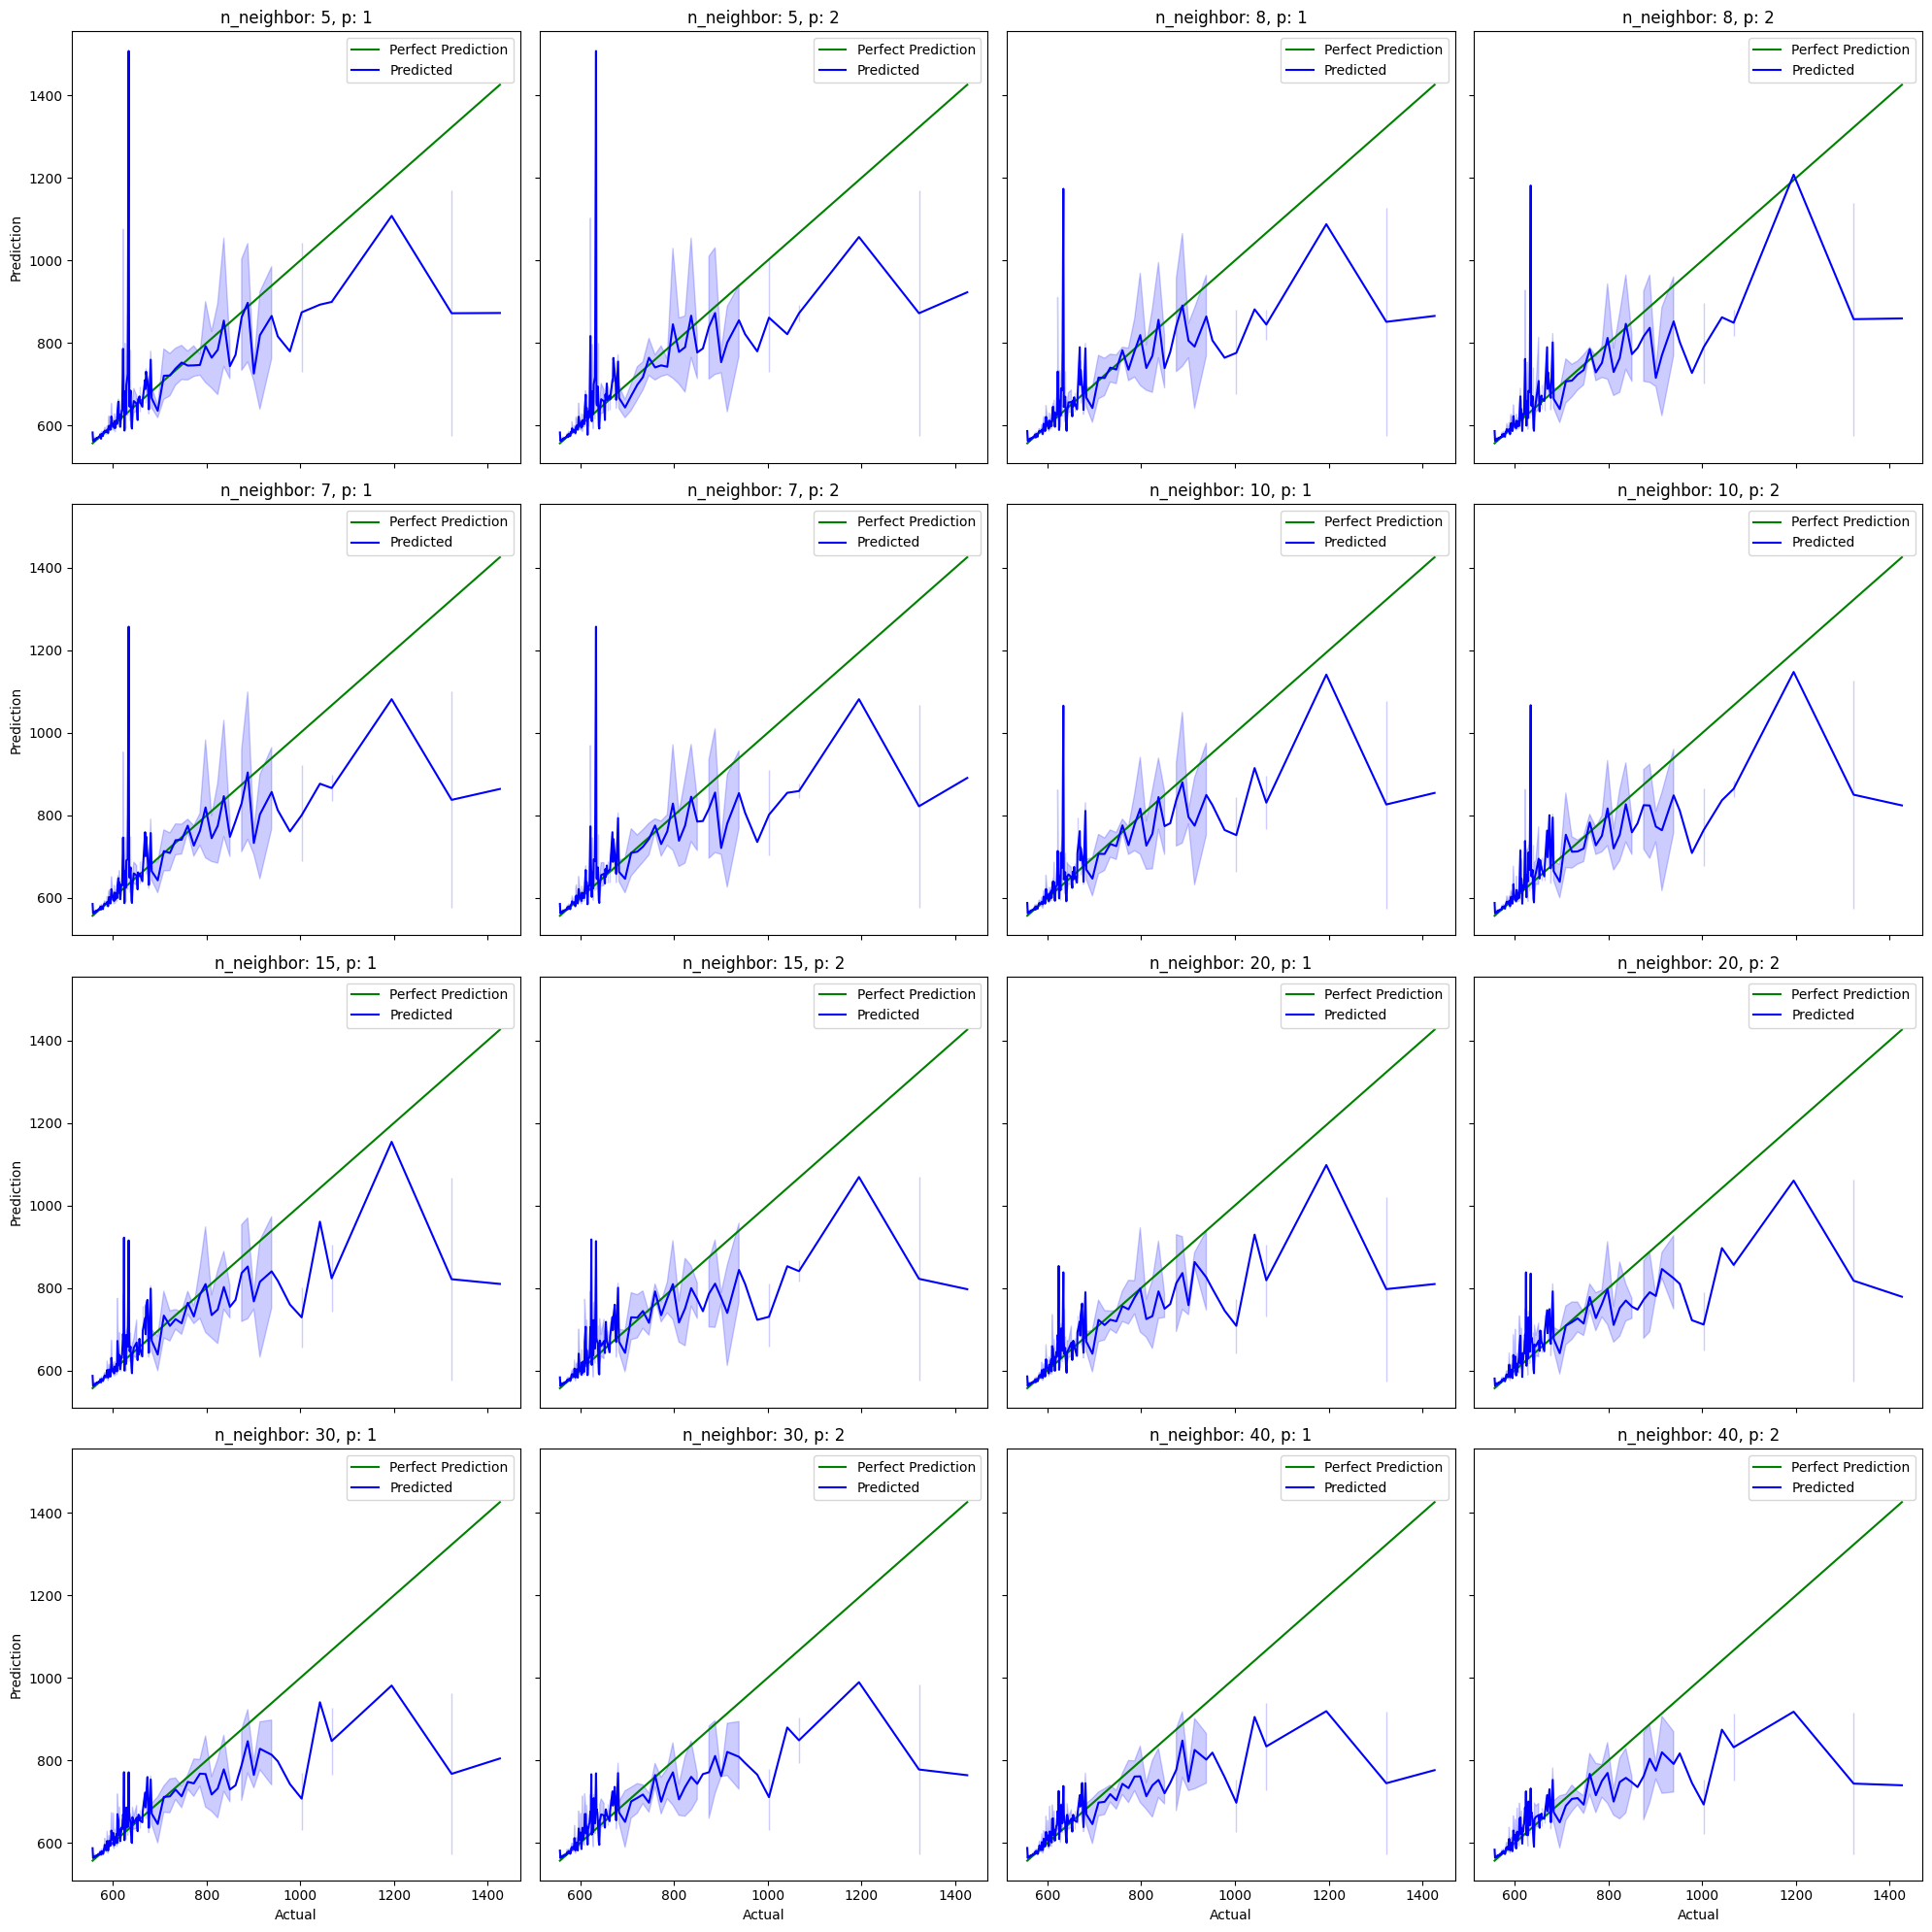

In [ ]:
# Visualize the predictions vs actual of testing set for each n_neighbor and p
# Assuming we have 16 combinations (8 n_neighbor * 2 p)
fig, axes = plt.subplots(4,4, figsize=(20, 20), sharex=True, sharey=True)
axes = axes.flatten()

for i, (n, P, y_test_pred) in enumerate(zip(n_neighbor_list, p_value_list, y_test_preds)):
    # Create DataFrame with actual and predicted values for testing data
    df_test = pd.DataFrame({'Actual': y_test.values.flatten(), 'Prediction': y_test_pred.flatten()})

    # Plot the perfect prediction line (Actual == Prediction)
    sns.lineplot(x='Actual', y='Actual', data=df_test, ax=axes[i], color='green', label='Perfect Prediction')

    # Plot the predictions from the model (testing data)
    sns.lineplot(x='Actual', y='Prediction', data=df_test, ax=axes[i], color='blue', label='Predicted')

    # Set the title with alpha and l1_ratio value
    axes[i].set_title(f'n_neighbor: {n}, p: {P}')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Prediction')

# Adjust layout and show plot
plt.tight_layout()
plt.show()